# Disease Sample Scoring Pipeline

| Branch | 모델 | Score | 해석 |
|--------|------|-------|------|
| NBI (det≥10%) | GAMLSS NBI | z_nbi | 발현량 이상도 (calibrated) |
| Logistic (1-10%) | Logistic Regression | z_logistic | 검출 확률 이상도 |
| Rare (det<1%) | Poisson / Fixed | rare_score | 희소 발현 이상도 (uncalibrated) |

In [ ]:
import sys, warnings
warnings.filterwarnings('ignore')
sys.path.insert(0, '.')

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import scanpy as sc
from scipy.sparse import issparse

from model_engine import NormativeModelEngine
from rare_event_scorer import RareEventScorer
from ..viz_style import apply_style
apply_style()

BASE_DIR   = Path('.').resolve()
DATA_DIR   = BASE_DIR.parent / 'OpenAccess_nfcore'
H5AD_PATH  = DATA_DIR / 'Merged_Processed_AnnData_with_Batch_Biases_QC_Status.h5ad'
ENGINE_DIR = BASE_DIR / 'engine_state'
RARE_REF   = BASE_DIR / 'CV_Results' / 'rare_event_ref.pkl'

print(f'BASE_DIR  : {BASE_DIR}')
print(f'H5AD_PATH : {H5AD_PATH}')
print(f'Exists    : {H5AD_PATH.exists()}')

PALETTE = {'NBI': '#E41A1C', 'ZINBI': '#377EB8', 'Logistic': '#4DAF4A',
           'Rare': '#984EA3'}
BIAS_COLUMNS = [
    'log(Total Reads)', 'Spliced Reads (%)',
    'gDNA Contamination (Intron/Exon)', 'rRNA Fraction',
    "RNA Degradation (3' Bias)", 'Platelet Score',
    'GC Bias', 'Gene Length Bias', 'NG80', '(NP80/NG80)',
]


In [2]:
if (ENGINE_DIR / 'genes.pkl').exists():
    print('Loading saved engine...')
    engine = NormativeModelEngine.load(ENGINE_DIR)
else:
    print('Engine not found. Training from scratch...')
    engine = NormativeModelEngine(
        count_model         = 'nbi',
        low_det_thr         = 0.10,   # Logistic: det < 10%, NBI: det >= 10%
        det_rate_min        = 0.01,   # det < 1% → rare_event_scorer 담당
        nbi_outlier_z       = 5.0,
        nbi_max_iter        = 2,
        nbi_max_remove_frac = 0.10,
        lambda_sigma        = 0.05,
    )
    engine.load_hc_data(H5AD_PATH)
    engine.assign_branches()
    engine.train(verbose=True)
    engine.save(ENGINE_DIR)

print(f'  NBI genes   : {len(engine.count_genes):,}')
print(f'  Logistic    : {len(engine.logistic_genes):,}')

# Rare event scorer
if RARE_REF.exists():
    rare_scorer = RareEventScorer.load(RARE_REF)
else:
    print('Building rare event reference...')
    rare_scorer = RareEventScorer.from_h5ad(H5AD_PATH)
    rare_scorer.save(RARE_REF)

Loading saved engine...
Engine loaded from /project/cfRNA_NormativeModeling/Modeling/engine_state/  (19538 fitted genes)
  NBI genes   : 16,570
  Logistic    : 2,968
Loaded reference: 559 rare genes


## 2. Disease 샘플 로드

In [3]:
print('Loading h5ad...')
adata = sc.read_h5ad(H5AD_PATH)
obs_mask = (
    (adata.obs['QC_Passed'] == True) &
    (adata.obs['Phenotype_Processed'].notna()) &
    (adata.obs['Phenotype_Processed'] != 'Unknown') &
    (adata.obs['broad_protocol_category'] != 'Exome-based (EB)')
)

var_mask = (adata.var['GeneType'] == 'protein_coding')
adata = adata[obs_mask, var_mask].copy()
is_hc  = (adata.obs['Phenotype_Processed'].astype(str) == 'Healthy Control').values
is_dis = ~is_hc

Y = adata.X.toarray() if issparse(adata.X) else np.asarray(adata.X)
Y = np.round(Y).astype(np.float32)

X_raw      = adata.obs[BIAS_COLUMNS].values.astype(np.float64)
sample_ids = adata.obs_names.tolist()
gene_names = adata.var_names.tolist()
phenotypes = adata.obs['Phenotype_Processed'].astype(str).values

dis_idx    = np.where(is_dis)[0]
dis_names  = [sample_ids[i] for i in dis_idx]
dis_pheno  = phenotypes[dis_idx]

print(f'HC: {is_hc.sum()}  Disease: {is_dis.sum()}')
print(pd.Series(dis_pheno).value_counts().to_string())

Loading h5ad...
HC: 693  Disease: 913
CDCS                  224
Tuberculosis          103
ME/CFS                 90
Pancreatitis           81
Pancreatic Cancer      74
Pre-eclampsia          62
Liver Cancer           48
Colorectal Cancer      41
Lung Cancer            33
Stomach Cancer         29
Esophagus Cancer       27
MM                     18
Other Cancer           18
HIV                    13
HIV + Tuberculosis     11
ICI-m                  11
ICI-treated Cancer     11
MGUS                    8
Pancreatic Cancer       6
Liver Cirrhosis         5


## 3. 샘플별 Scoring 함수

In [4]:
from scipy.stats import poisson as _poisson, norm as _norm

# ── Batch score: engine once, numpy 변환 ─────────────────────────
def score_all(X_dis: np.ndarray,
              Y_dis: np.ndarray,
              sample_names: list,
              pheno_names:  list,
              min_abs_score: float = 3.0) -> pd.DataFrame:
    n_dis  = len(sample_names)
    sa_arr = np.array(sample_names)
    ph_arr = np.array(pheno_names)
    import time; t0 = time.perf_counter()
    print(f'Engine scoring {n_dis} samples × {len(gene_names):,} genes...')
    result = engine.score(X_dis, Y_dis, gene_names=gene_names, seed=42)
    print(f'  engine done: {time.perf_counter()-t0:.1f}s')
    Z      = result['combined']           # (n_dis, n_genes)  float32
    g_arr  = np.array(result['gene_names'])
    n_g    = len(g_arr)
    branch_of = np.array([
        'logistic' if (r := engine.genes.get(g)) and r.branch == 'logistic'
        else 'count'
        for g in g_arr
    ])
    stype_of = np.where(branch_of == 'logistic', 'logistic_z', 'nbi_z')
    # ── 2. Long-format via numpy (no Python sample loop) ─────
    mask = np.abs(Z) >= min_abs_score if min_abs_score > 0 else np.isfinite(Z)
    row_s, row_g = np.nonzero(mask)      # (k,) sample idx, gene idx
    df_engine = pd.DataFrame({
        'sample':     sa_arr[row_s],
        'phenotype':  ph_arr[row_s],
        'gene':       g_arr[row_g],
        'score':      Z[row_s, row_g].astype(float),
        'score_type': stype_of[row_g],
        'raw_count':  Y_dis[row_s, row_g].astype(float),
        'branch':     branch_of[row_g],
    })
    print(f'  engine rows (|z|≥{min_abs_score}): {len(df_engine):,}')
    # ── 3. Rare event: vectorized ─────────────────────────────
    ref      = rare_scorer.ref
    r_genes  = ref['gene'].values
    r_mean   = ref['mean_hc'].values.astype(float)
    r_det    = ref['det_rate_hc'].values.astype(float)
    r_cat    = ref['category'].values
    gn_map   = {g: i for i, g in enumerate(gene_names)}
    r_cols   = np.array([gn_map.get(g, -1) for g in r_genes])
    valid    = r_cols >= 0
    r_cols, r_genes = r_cols[valid], r_genes[valid]
    r_mean, r_det, r_cat = r_mean[valid], r_det[valid], r_cat[valid]
    Y_rare   = Y_dis[:, r_cols].astype(float)   # (n_dis, n_rare)
    nonzero  = Y_rare > 0
    silent   = (r_det == 0)[np.newaxis, :]
    sc_rare  = np.zeros_like(Y_rare, dtype=np.float32)
    sc_rare[silent & nonzero] = 10.0
    near = (~silent) & nonzero
    if near.any():
        k_n   = Y_rare[near].astype(int)
        mu_n  = np.broadcast_to(r_mean[np.newaxis, :], Y_rare.shape)[near]
        pv    = _poisson.sf(k_n - 1, mu_n)
        sc_rare[near] = np.where(
            pv <= 0, 10.0, np.minimum(_norm.ppf(1.0 - pv), 10.0)
        ).astype(np.float32)

    rs, rg = np.nonzero(sc_rare >= max(min_abs_score, 0.01))
    if len(rs):
        df_rare = pd.DataFrame({
            'sample':     sa_arr[rs],
            'phenotype':  ph_arr[rs],
            'gene':       r_genes[rg],
            'score':      sc_rare[rs, rg].astype(float),
            'score_type': np.where(r_cat[rg] == 'silent', 'rare_fixed', 'rare_poisson'),
            'raw_count':  Y_rare[rs, rg],
            'branch':     'rare',
        })
        df_engine = pd.concat([df_engine, df_rare], ignore_index=True)
        print(f'  rare rows: {len(df_rare):,}')

    print(f'Total: {len(df_engine):,} rows  elapsed: {time.perf_counter()-t0:.1f}s')
    return df_engine

# ── 단일 샘플 래퍼 (시각화용) ─────────────────────────────────────
def score_sample(sample_idx: int) -> pd.DataFrame:
    df = score_all(
        X_raw[[sample_idx]], Y[[sample_idx]],
        [sample_ids[sample_idx]], [phenotypes[sample_idx]],
        min_abs_score=0.0,
    )
    return df.drop(columns=['sample', 'phenotype'])

print('Scorer ready. Use score_all(X_dis, Y_dis, sample_names, pheno_names).')

Scorer ready. Use score_all(X_dis, Y_dis, sample_names, pheno_names).


## 4. Per-Sample Visualization

In [5]:
BRANCH_COLOR = {
    'count':    PALETTE['NBI'],
    'logistic': PALETTE['Logistic'],
    'rare':     PALETTE['Rare'],
}
Z_FLAG = 3.0   
def plot_sample(df: pd.DataFrame, sample_id: str,
                phenotype: str = '', top_n: int = 20):
    df = df.dropna(subset=['score']).copy()
    df['abs_score'] = df['score'].abs()
    df_sorted = df.sort_values('score', ascending=False).reset_index(drop=True)
    flagged = df[df['abs_score'] >= Z_FLAG].sort_values('abs_score', ascending=False)
    fig, axes = plt.subplots(1, 2, figsize=(18, 5), gridspec_kw={'width_ratios': [3, 1]})

    # ── Left: Manhattan-style ─────────────────────────────────
    ax = axes[0]
    for branch, sub in df_sorted.groupby('branch'):
        ax.scatter(sub.index, sub['score'],
                   s=1, alpha=0.8, color=BRANCH_COLOR.get(branch, 'grey'),
                   label=branch, rasterized=True)

    flag_sub = df_sorted[df_sorted['abs_score'] >= Z_FLAG]
    ax.scatter(flag_sub.index, flag_sub['score'],
               s=5, color='black', zorder=5, alpha=0.8)
    for _, row in flag_sub.head(5).iterrows():
        ax.annotate(row['gene'], (row.name, row['score']),
                    xytext=(5, 3), textcoords='offset points',
                    fontsize=7, alpha=0.85)

    ax.axhline(Z_FLAG,  color='red',  lw=1, ls='--', alpha=0.6,
               label=f'|z|={Z_FLAG}')
    ax.axhline(-Z_FLAG, color='red',  lw=1, ls='--', alpha=0.6)
    ax.axhline(0, color='grey', lw=0.8, ls='-', alpha=0.4)
    ax.set_xlabel('Genes (sorted by score)', fontsize=10)
    ax.set_ylabel('Anomaly Score (z / rare_score)', fontsize=10)
    ax.set_title(f'{sample_id}\n{phenotype}', fontweight='bold')
    ax.legend(fontsize=8, loc='upper right')
    # ── Right: Top flagged genes ──────────────────────────────
    ax2 = axes[1]
    top = flagged.head(top_n)
    if len(top) == 0:
        ax2.text(0.5, 0.5, 'No flagged genes', ha='center', va='center',
                 transform=ax2.transAxes, color='grey')
        ax2.axis('off')
    else:
        colors = [BRANCH_COLOR.get(b, 'grey') for b in top['branch']]
        bars   = ax2.barh(range(len(top)), top['abs_score'].values,
                          color=colors, alpha=0.8, edgecolor='white')
        ax2.set_yticks(range(len(top)))
        ax2.set_yticklabels(
            [f"{g}  ({c:.0f}ct)" for g, c in
             zip(top['gene'], top['raw_count'].fillna(0))],
            fontsize=7
        )
        ax2.invert_yaxis()
        ax2.axvline(Z_FLAG, color='red', lw=1, ls='--', alpha=0.6)
        
        ax2.set_xlabel('|Score|')
        ax2.set_title(f'Top {len(top)} Flagged Genes', fontweight='bold')
        # branch legend
        from matplotlib.patches import Patch
        legend_els = [Patch(facecolor=c, label=b)
                      for b, c in BRANCH_COLOR.items()]
        ax2.legend(handles=legend_els, fontsize=7, loc='lower right')

    plt.tight_layout()
    return fig

print('Visualization functions ready.')

Visualization functions ready.


## 5. 예시: 질환별 대표 샘플 스코어링


Scoring Liver Cancer: SRR14506726
Engine scoring 1 samples × 20,097 genes...
  engine done: 2.6s
  engine rows (|z|≥0.0): 19,538
  rare rows: 14
Total: 19,552 rows  elapsed: 2.7s
  Flagged genes: 252
  Top 5 by |score|:
              gene  score   score_type  raw_count
ENSG00000092377.15   10.0 rare_poisson       11.0
 ENSG00000142513.6   10.0 rare_poisson        9.0
 ENSG00000150750.9   10.0 rare_poisson       12.0
 ENSG00000172208.7   10.0 rare_poisson       10.0
ENSG00000185681.14   10.0 rare_poisson       36.0


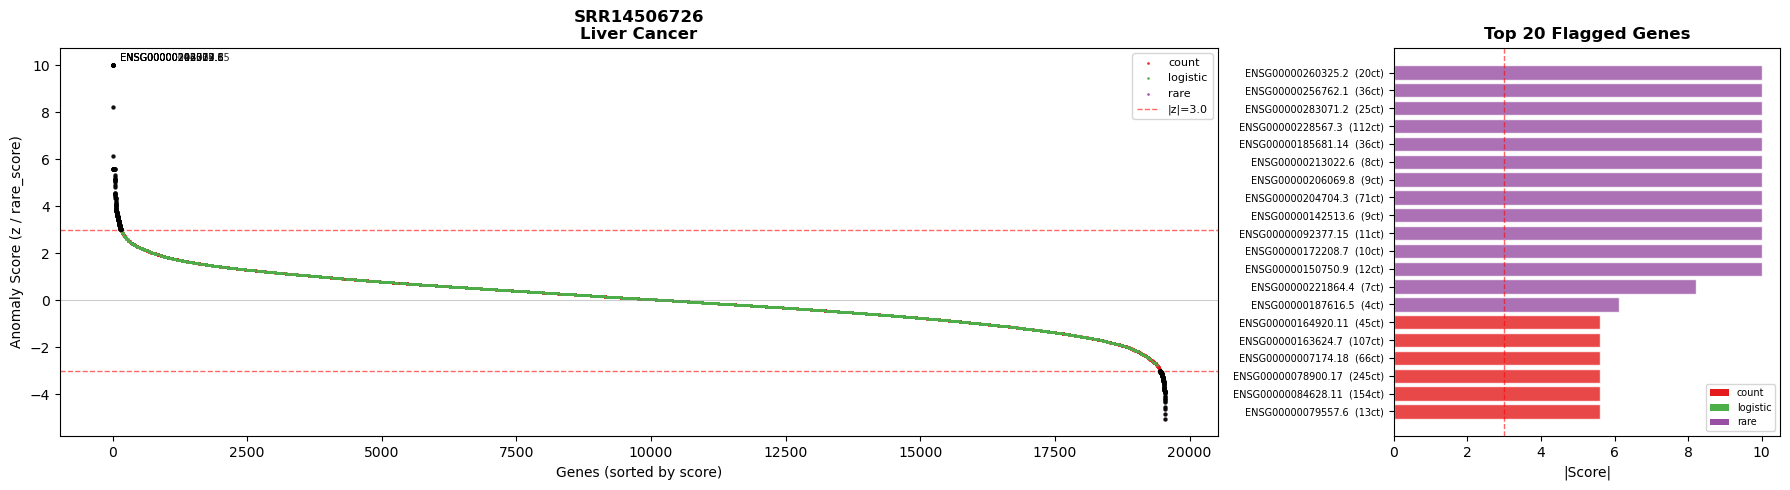


Scoring Pancreatic Cancer: SRR29803839
Engine scoring 1 samples × 20,097 genes...
  engine done: 2.7s
  engine rows (|z|≥0.0): 19,538
Total: 19,538 rows  elapsed: 2.7s
  Flagged genes: 45
  Top 5 by |score|:
              gene    score score_type  raw_count
ENSG00000204296.13 5.612001      nbi_z       58.0
 ENSG00000248329.7 5.612001      nbi_z        4.0
ENSG00000154274.16 5.057833      nbi_z       96.0
 ENSG00000284931.1 4.548844      nbi_z    70420.0
ENSG00000008323.17 3.926100      nbi_z       79.0


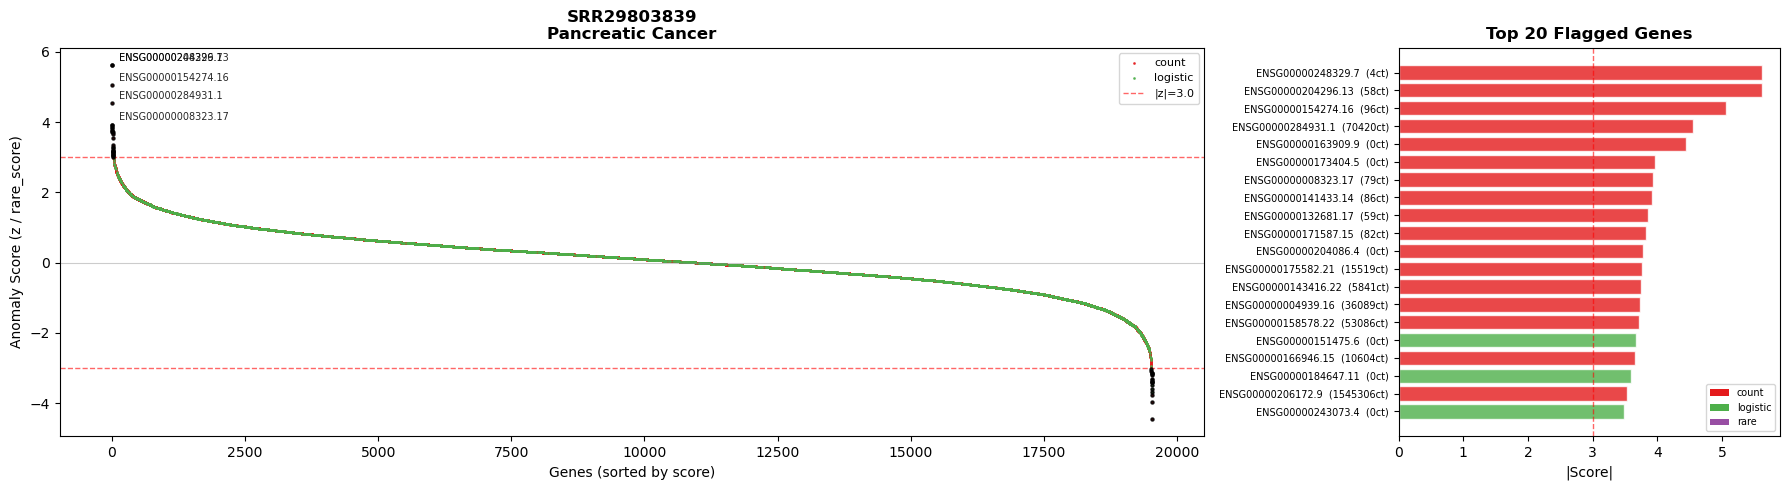


Scoring Tuberculosis: SRR28475979
Engine scoring 1 samples × 20,097 genes...
  engine done: 2.6s
  engine rows (|z|≥0.0): 19,538
  rare rows: 4
Total: 19,542 rows  elapsed: 2.6s
  Flagged genes: 92
  Top 5 by |score|:
              gene    score   score_type  raw_count
ENSG00000142657.22 5.612001        nbi_z     1268.0
ENSG00000021355.14 5.501016        nbi_z     1218.0
ENSG00000143546.11 5.331437        nbi_z    16328.0
 ENSG00000171459.4 5.099282 rare_poisson        3.0
ENSG00000100504.18 5.097613        nbi_z     1001.0


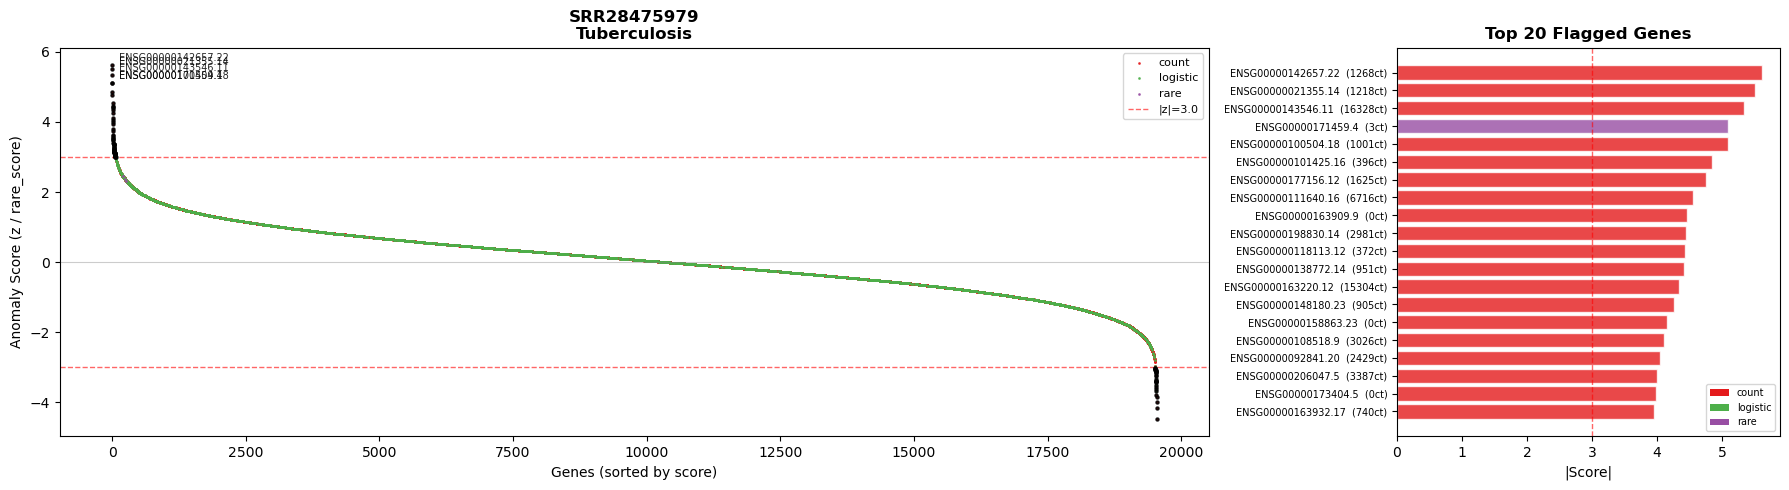

In [ ]:
# 각 질환 조건에서 첫 번째 샘플 선택
example_phenos = ['Liver Cancer', 'Pancreatic Cancer', 'Tuberculosis']

for pheno in example_phenos:
    mask = (phenotypes == pheno) & is_dis
    if not mask.any():
        print(f'{pheno}: 샘플 없음'); continue

    idx  = np.where(mask)[0][1]
    sid  = sample_ids[idx]
    print(f'\nScoring {pheno}: {sid}')

    df = score_sample(idx)
    flagged = df[df['score'].abs() >= Z_FLAG]
    print(f'  Flagged genes: {len(flagged)}')
    print(f'  Top 5 by |score|:')
    print(flagged.nlargest(5, 'score')[['gene','score','score_type','raw_count']].to_string(index=False))

    fig = plot_sample(df, sid, pheno)
    plt.savefig(BASE_DIR / 'CV_Results' / "Figures" / f'score_{pheno.replace(" ", "_")}.png',
                bbox_inches='tight', dpi=150)
    plt.show()

## 6. 전체 Disease 샘플 Batch 스코어링

In [ ]:
X_dis = X_raw[dis_idx]
Y_dis = Y[dis_idx]

# ── 1. Full Z matrix (all genes, no threshold) ────────────────────
print("Computing full Z matrix...")
import time; t0 = time.perf_counter()
result_full = engine.score(X_dis, Y_dis, gene_names=gene_names, seed=42)
Z_full = result_full["combined"]   # (n_dis, n_all_genes) float32
print(f"Z matrix: {Z_full.shape}  {Z_full.nbytes/1e6:.0f} MB  ({time.perf_counter()-t0:.1f}s)")

# ── 2. Save wide matrix ───────────────────────────────────────────
import numpy as np
z_path  = BASE_DIR / "CV_Results" / "Z_disease.npy"
sn_path = BASE_DIR / "CV_Results" / "Z_sample_names.npy"
gn_path = BASE_DIR / "CV_Results" / "Z_gene_names.npy"

np.save(z_path,  Z_full)
np.save(sn_path, np.array(dis_names))
np.save(gn_path, np.array(gene_names))
print(f"Saved: {z_path.name}  {z_path.stat().st_size/1e6:.0f} MB")

# ── 3. Filtered long format for quick analysis (|z|>=3) ───────────
from scipy.stats import poisson as _poisson, norm as _norm

# Rare event scores (vectorized)
ref    = rare_scorer.ref
r_genes = ref["gene"].values
r_mean  = ref["mean_hc"].values.astype(float)
r_det   = ref["det_rate_hc"].values.astype(float)
r_cat   = ref["category"].values
gn_map  = {g: i for i, g in enumerate(gene_names)}
r_cols  = np.array([gn_map.get(g, -1) for g in r_genes])
valid   = r_cols >= 0
r_cols, r_genes = r_cols[valid], r_genes[valid]
r_mean, r_det, r_cat = r_mean[valid], r_det[valid], r_cat[valid]
Y_rare  = Y_dis[:, r_cols].astype(float)
nonzero = Y_rare > 0
silent  = (r_det == 0)[np.newaxis, :]
sc_rare = np.zeros_like(Y_rare, dtype=np.float32)
sc_rare[silent & nonzero] = 10.0
near = (~silent) & nonzero
if near.any():
    k_n  = Y_rare[near].astype(int)
    mu_n = np.broadcast_to(r_mean[np.newaxis,:], Y_rare.shape)[near]
    pv   = _poisson.sf(k_n - 1, mu_n)
    sc_rare[near] = np.where(pv<=0, 10.0, np.minimum(_norm.ppf(1.0-pv), 10.0)).astype(np.float32)

# Engine long-format (|z|>=3.0)
sa_arr = np.array(dis_names); ph_arr = np.array(dis_pheno)
g_arr  = np.array(result_full["gene_names"])
branch_of = np.array([
    "logistic" if (r:=engine.genes.get(g)) and r.branch=="logistic" else "count"
    for g in g_arr])
stype_of  = np.where(branch_of=="logistic", "logistic_z", "nbi_z")

THR = 3.0
row_s, row_g = np.nonzero(np.abs(Z_full) >= THR)
all_scores = pd.DataFrame({
    "sample":    sa_arr[row_s],
    "phenotype": ph_arr[row_s],
    "gene":      g_arr[row_g],
    "score":     Z_full[row_s, row_g].astype(float),
    "score_type":stype_of[row_g],
    "raw_count": Y_dis[row_s, row_g].astype(float),
    "branch":    branch_of[row_g],
})
rs, rg = np.nonzero(sc_rare >= 3.0)
if len(rs):
    df_r = pd.DataFrame({
        "sample":    sa_arr[rs], "phenotype": ph_arr[rs],
        "gene":      r_genes[rg],
        "score":     sc_rare[rs,rg].astype(float),
        "score_type":np.where(r_cat[rg]=="silent","rare_fixed","rare_poisson"),
        "raw_count": Y_rare[rs,rg], "branch": "rare",
    })
    all_scores = pd.concat([all_scores, df_r], ignore_index=True)

out_path = BASE_DIR / "CV_Results" / "disease_scores_flagged.parquet"
all_scores.to_parquet(out_path, index=False)
print(f"Flagged long format: {len(all_scores):,} rows → {out_path.name}")

# Z_FLAG 변수 (시각화 셀에서 사용)
Z_FLAG = THR
print(f"Done. Z_FLAG={Z_FLAG}")

Computing full Z matrix...
Z matrix: (913, 20097)  73 MB  (11.1s)
Saved: Z_disease.npy  73 MB
Flagged long format: 280,301 rows → disease_scores_flagged.parquet
Done. Z_FLAG=3.0
